# **Classification**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, 
    MinMaxScaler, 
    OrdinalEncoder, 
    KBinsDiscretizer, 
    FunctionTransformer, 
    label_binarize
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc
)

In [2]:
file_name= "..\\dm1_25_26_dataset\\cleaned_dataset.csv"
df = pd.read_csv(file_name)

### **Distribution of multiclass target variable**

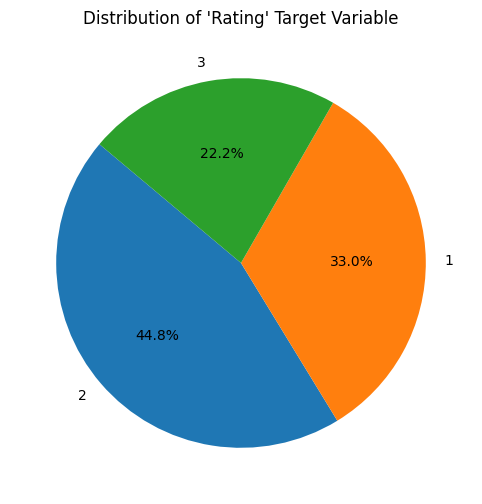

In [3]:
# pie chart of the distribution of 'Rating' target variable
rating_counts = df['Rating'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of 'Rating' Target Variable")
plt.show()

### **Creation and distribution visualization of binary target variable**

In [4]:
# Descriptive Statistics of ComMaxPlaytime to decide threshold for binary classification
print(df['ComMaxPlaytime'].describe())

# We calculate specific percentiles to understand the distribution shape
# and to verify where the majority of the games fall.
percentiles = [25, 50, 75, 90]
percentile_values = np.percentile(df['ComMaxPlaytime'].dropna(), percentiles)

print(f"\n25% of the games last less than: {percentile_values[0]} min")
print(f"50% of the games (Median) last less than: {percentile_values[1]} min")
print(f"75% of the games last less than: {percentile_values[2]} min")
print(f"90% of the games last less than: {percentile_values[3]} min")

count    19729.000000
mean        63.924223
std         56.178342
min          1.000000
25%         30.000000
50%         45.000000
75%         90.000000
max        360.000000
Name: ComMaxPlaytime, dtype: float64

25% of the games last less than: 30.0 min
50% of the games (Median) last less than: 45.0 min
75% of the games last less than: 90.0 min
90% of the games last less than: 120.0 min


--- Class Distribution with threshold 60 min ---
Class 0 (Fast < 60m):  56.33%
Class 1 (Long >=60m):  43.67%

[OK] Class balance is suitable for training.


C:\Users\elisa\AppData\Local\Temp\ipykernel_41152\3050065468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_long_game', data=df, palette='coolwarm')


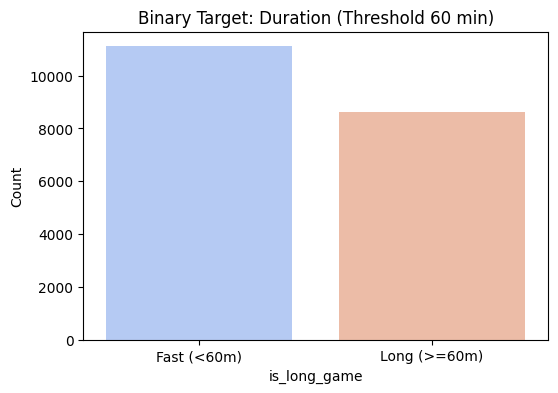

In [5]:
# setting a threshold (t) for binary classification 
# Games >= t will be labeled as "Long" (1)
# Games < t will be labeled as "Fast" (0)

THRESHOLD_MINUTES = 60

df['is_long_game'] = (df['ComMaxPlaytime'] >= THRESHOLD_MINUTES).astype(int)

# Calculate the percentage distribution of the two classes
counts = df['is_long_game'].value_counts(normalize=True) * 100
print(f"--- Class Distribution with threshold {THRESHOLD_MINUTES} min ---")
print(f"Class 0 (Fast < {THRESHOLD_MINUTES}m):  {counts[0]:.2f}%")
print(f"Class 1 (Long >={THRESHOLD_MINUTES}m):  {counts[1]:.2f}%")

# Automated check: If the minority class is too small (under 30%), warn the user.
if counts[1] < 30:
    print("\n[!] WARNING: The 'Long' class is underrepresented. Consider lowering the threshold to the median (45 min).")
else:
    print("\n[OK] Class balance is suitable for training.")

# plot the distribution with threshold=90 
plt.figure(figsize=(6, 4))
sns.countplot(x='is_long_game', data=df, palette='coolwarm')
plt.title(f'Binary Target: Duration (Threshold {THRESHOLD_MINUTES} min)')
plt.xticks([0, 1], [f'Fast (<{THRESHOLD_MINUTES}m)', f'Long (>={THRESHOLD_MINUTES}m)'])
plt.ylabel('Count')
plt.show()

### **Train-test split**

In [6]:
X = df.drop(columns=['Rating', 'is_long_game'])
y = df[['Rating', 'is_long_game']]

# Stratified split (80-20) on the most complex variable (Rating) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df['Rating']
)

### **KNN Classifier - Multiclass classification**

#### Selecting features 

In [7]:
features_knn_multi = [
    'Avg_popularity_log',
    'YearPublished',
    'Kickstarted',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'NumWeightVotes_log',
    'ComMinPlaytime',
]

X_train_knn_multi = X_train[features_knn_multi]
y_train_knn_multi = y_train['Rating'] 
X_test_knn_multi = X_test[features_knn_multi]
y_test_knn_multi = y_test['Rating']

#### Hyperparameter Tuning using Grid Search technique and Cross-Validation

Il codice prova tutte le combinazioni possibili e seleziona la migliore: proverà tutti i k da 1 a 30, entrambe le metriche (euclidean/manhattan) e entrambi i metodi di pesatura dei voti ('uniform' e 'distance').

Ciascuna delle 120 combinazioni risultanti viene sottoposta a una Cross-Validation a 5 fold (suddividendo il training set in 5 parti e validando a rotazione). La metrica utilizzata per decretare la configurazione vincitrice è il Macro-Averaged F1-Score. Questa scelta è cruciale per evitare che il modello favorisca le classi maggioritarie: l'ottimizzazione mira a trovare l'equilibrio ideale tra precision e recall per tutte le classi, minimizzando il rischio di overfitting e garantendo una generalizzazione robusta sui nuovi dati.

In [8]:
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier())
])

# Define the parameter grid to test
# We list all the options we want the algorithm to explore
param_grid = {
    'knn__n_neighbors': range(1, 31),            # Try K values from 1 to 30
    'knn__weights': ['uniform', 'distance'],     # Try both uniform and distance-weighted voting
    'knn__metric': ['euclidean', 'manhattan']    # Try Euclidean and Manhattan (Cityblock) distances
}


# Configure the automatic search (GridSearchCV)
# cv=5: Uses 5-fold Cross-Validation (robust standard)
# scoring='f1_macro': Key metric for imbalanced classes (balances precision and recall)
# n_jobs=-1: Uses all available processor cores to speed up calculation

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")
grid_search.fit(X_train_knn_multi, y_train_knn_multi)


# Print the results to match the report style
print(f"\nBEST CONFIGURATION FOUND:")
print(f"-------------------------------")
print(f"Best params: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.2%}")

# Save the best model to a variable for final testing
best_knn_multi = grid_search.best_estimator_

# Final evaluation on the held-out Test Set
pred_optimized = best_knn_multi.predict(X_test_knn_multi)
print("\nFinal Results on Test Set:")
print(classification_report(y_test_knn_multi, pred_optimized))


Starting hyperparameter tuning...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

BEST CONFIGURATION FOUND:
-------------------------------
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 30, 'knn__weights': 'distance'}
Best Cross-Validation F1-Score: 64.77%

Final Results on Test Set:
              precision    recall  f1-score   support

           1       0.69      0.69      0.69      1301
           2       0.63      0.69      0.66      1769
           3       0.74      0.58      0.65       876

    accuracy                           0.67      3946
   macro avg       0.69      0.66      0.67      3946
weighted avg       0.67      0.67      0.67      3946



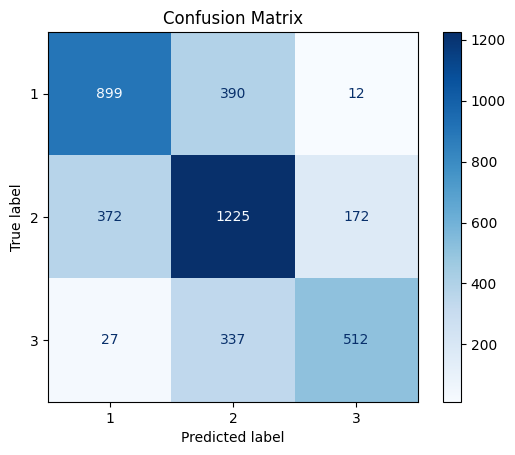

In [9]:
# Confusion Matrix for the Test Set
ConfusionMatrixDisplay.from_predictions(
    y_test_knn_multi, pred_optimized, cmap='Blues', display_labels=best_knn_multi.classes_
)
plt.title(f"Confusion Matrix")
plt.show()

### **KNN Classifier - Binary classification**

#### Selecting features 

In [10]:
features_knn_bi = [
    'Avg_popularity_log',
    'YearPublished',
    'Kickstarted',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'NumAlternates_log',
    'ComAgeRec',
]

X_train_knn_bi = X_train[features_knn_bi]
y_train_knn_bi = y_train['is_long_game'] 
X_test_knn_bi = X_test[features_knn_bi]
y_test_knn_bi = y_test['is_long_game']

#### Hyperparameter Tuning using Grid Search technique and Cross-Validation


In [11]:
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier())
])

# Define the parameter grid to test
# We list all the options we want the algorithm to explore
param_grid = {
    "knn__n_neighbors": range(1, 31),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",   # binary classification -> f1 score
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning for binary classification...")
grid_search.fit(X_train_knn_bi, y_train_knn_bi)

# Print the results to match the report style
print(f"\nBEST CONFIGURATION FOUND:")
print(f"-------------------------------")
print(f"Best params: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.2%}")

# Save the best model to a variable for final testing
best_knn_bi = grid_search.best_estimator_

# Final evaluation on the held-out Test Set
pred_optimized = best_knn_bi.predict(X_test_knn_bi)
print("\nFinal Results on Test Set:")
print(classification_report(y_test_knn_bi, pred_optimized))

Starting hyperparameter tuning for binary classification...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

BEST CONFIGURATION FOUND:
-------------------------------
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 25, 'knn__weights': 'uniform'}
Best Cross-Validation F1-Score: 77.94%

Final Results on Test Set:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      2270
           1       0.80      0.75      0.77      1676

    accuracy                           0.81      3946
   macro avg       0.81      0.80      0.81      3946
weighted avg       0.81      0.81      0.81      3946



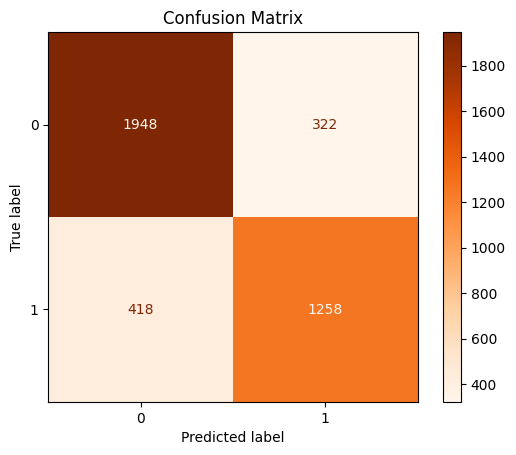

In [12]:
# Confusion matrix visualization
ConfusionMatrixDisplay.from_predictions(
    y_test_knn_bi, pred_optimized, cmap='Oranges'
)
plt.title('Confusion Matrix')
plt.show()

### **Naive Bayes Classifier**

#### GaussianNB()
progettato per gestire **variabili continue** (numeri reali come temperatura, altezza o peso). Il suo funzionamento si basa sull'assunzione statistica che i dati di ogni classe seguano una distribuzione normale (o Gaussiana/a campana). Il modello calcola per ogni feature media e deviazione standard e usa questi parametri per stimare la probabilità che un dato valora appartenga a una certa classe. e applicato a dati categorici o binari (dove esistono solo 0 e 1 e nulla in mezzo), il modello commette un errore concettuale: cerca di adattare una curva continua a dati "a gradini", assegnando probabilità a valori intermedi inesistenti e riducendo l'accuratezza delle predizioni.
 
#### CategoricalNB()
progettato per lavorare con **variabili discrete**. Non assume alcuna forma a campana dei dati e ha un approccio basato sulla frequenza. L'algoritmo assume che le feature seguano una distribuzione categorica (o Multinoulli) e calcola le probabilità semplicemente contando quanto spesso ogni categoria appare in ciascuna classe. Se si vuole usare una variabile continua  bisogna prima trasformarla con la **discretizzazione** (binning). Sklearn però non accetta stringhe, quindi le categorie devono essere trasformate in numeri interi progressivi con l'OrdinalEncoder.


#### Multiclass classification with **GaussianNB()**

In [13]:
# select continuous features only
continuous_features_multi_Gnb = [
    'Avg_popularity_log', 
    'GameWeight', 
    'MaxPlayers',
    'MinPlayers',
    'NumAlternates_log', 
    'YearPublished',
]

X_train_multi_Gnb = X_train[continuous_features_multi_Gnb]
y_train_multi_Gnb = y_train['Rating'] 
X_test_multi_Gnb = X_test[continuous_features_multi_Gnb]
y_test_multi_Gnb = y_test['Rating']

#training with Gaussian
gnb = GaussianNB()
gnb.fit(X_train_multi_Gnb, y_train_multi_Gnb)

#predict
y_pred_multi_Gnb = gnb.predict(X_test_multi_Gnb)

#### Results 

In [14]:
# print classification report
print("\nGaussianNB Classification Report - Test Set:")
print(classification_report(y_test_multi_Gnb, y_pred_multi_Gnb))


GaussianNB Classification Report - Test Set:
              precision    recall  f1-score   support

           1       0.64      0.66      0.65      1301
           2       0.59      0.61      0.60      1769
           3       0.65      0.57      0.61       876

    accuracy                           0.62      3946
   macro avg       0.63      0.61      0.62      3946
weighted avg       0.62      0.62      0.62      3946



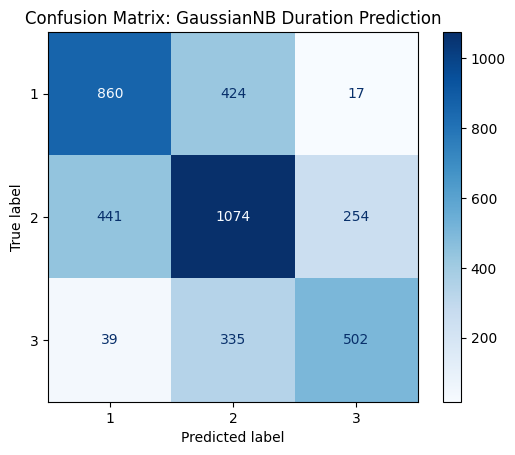

In [15]:
# visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_multi_Gnb, y_pred_multi_Gnb, cmap='Blues'
)
plt.title('Confusion Matrix: GaussianNB Duration Prediction')
plt.show()

#### Multiclass classification with **CategoricalNB()**

In [16]:
# Continuous features: These will be discretized into bins
continuous_features_multi_Cnb = [
    'GameWeight', 
    'MaxPlayers',
    'YearPublished',
    'NumAlternates_log',
    'Avg_popularity_log'
]

cat_features_multi_Cnb = [
    'MinPlayers',
    'Kickstarted'
]

all_features = continuous_features_multi_Cnb + cat_features_multi_Cnb

X_train_multi_Cnb = X_train[all_features]
X_test_multi_Cnb = X_test[all_features]
y_train_multi_Cnb = y_train['Rating']
y_test_multi_Cnb = y_test['Rating']

In [17]:
# 1. Setup the Preprocessor
# KBinsDiscretizer converts continuous values into discrete bins (0-4)
# OrdinalEncoder converts text categories into integers
# unknown_value=10 is used to keep all values positive, as CategoricalNB requires non-negative inputs
preprocessor = ColumnTransformer(
    transformers=[
        ('num', KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile'), continuous_features_multi_Cnb),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=10), cat_features_multi_Cnb)
    ]
)

# 2. Create the Pipeline
# This ensures preprocessing is applied correctly to both training and testing sets
cat_nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

# 3. Fit the model using your specific variables
cat_nb_model.fit(X_train_multi_Cnb, y_train_multi_Cnb)

# 4. Make predictions
y_pred_multi_Cnb = cat_nb_model.predict(X_test_multi_Cnb)


C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\

#### Results

In [18]:
print("--- Categorical Naive Bayes: Rating Classification ---")
print("\nClassification Report:")
print(classification_report(y_test_multi_Cnb, y_pred_multi_Cnb))

--- Categorical Naive Bayes: Rating Classification ---

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.68      0.68      1301
           2       0.60      0.65      0.62      1769
           3       0.66      0.54      0.60       876

    accuracy                           0.64      3946
   macro avg       0.65      0.62      0.63      3946
weighted avg       0.64      0.64      0.64      3946



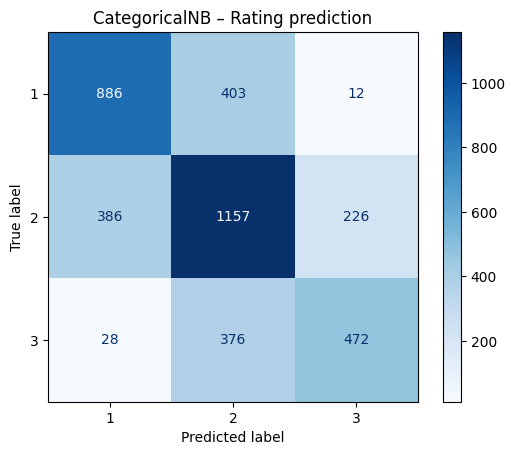

In [19]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_multi_Cnb,
    y_pred_multi_Cnb,
    cmap="Blues",
    display_labels=[1,2,3] # Corresponding to Low, Medium, High
)
plt.title("CategoricalNB – Rating prediction")
plt.grid(False)
plt.show()

#### Binary classification with **GaussianNB()**

In [20]:
# select continuous features only
continuous_features_bi_Gnb = [
    'Avg_popularity_log', 
    'ComAgeRec',
    'GameWeight', 
    'MaxPlayers',
   'NumExpansions_log', 
   'YearPublished',
   'MinPlayers'
]

# Create X and y
X_train_bi_Gnb = X_train[continuous_features_bi_Gnb]
X_test_bi_Gnb = X_test[continuous_features_bi_Gnb]
y_train_bi_Gnb = y_train['is_long_game']
y_test_bi_Gnb = y_test['is_long_game']

#training with Gaussian
gnb = GaussianNB()
gnb.fit(X_train_bi_Gnb, y_train_bi_Gnb)

#predict
y_pred_bi_Gnb = gnb.predict(X_test_bi_Gnb)

#### Results

In [21]:
print("--- Gaussian Naive Bayes: Binary Classification (is_long_game) ---")
print("\nClassification Report:")
print(classification_report(y_test_bi_Gnb, y_pred_bi_Gnb))

--- Gaussian Naive Bayes: Binary Classification (is_long_game) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      2270
           1       0.77      0.72      0.74      1676

    accuracy                           0.79      3946
   macro avg       0.79      0.78      0.78      3946
weighted avg       0.79      0.79      0.79      3946



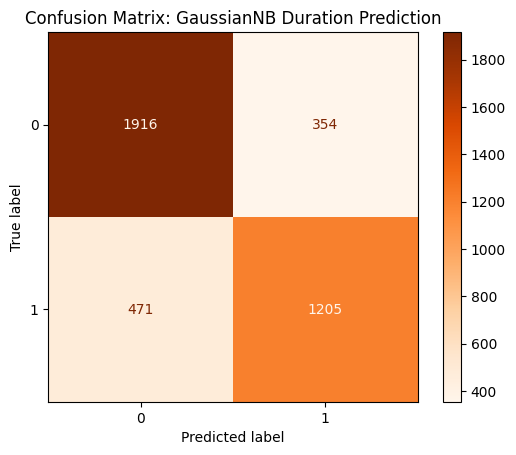

In [22]:
# visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_bi_Gnb, y_pred_bi_Gnb, cmap='Oranges'
)
plt.title('Confusion Matrix: GaussianNB Duration Prediction')
plt.show()

#### Binary classification with **CategoricalNB()**

In [23]:
# Continuous features: These will be discretized into bins
continuous_features_bi_Cnb = [
    'ComAgeRec',
    'GameWeight', 
    'MaxPlayers',
    'YearPublished',
    'NumWeightVotes_log',
    'Avg_popularity_log'
]

cat_features_bi_Cnb = [
    'MinPlayers',
    'Kickstarted',
]

all_features = continuous_features_bi_Cnb + cat_features_bi_Cnb

X_train_bi_Cnb = X_train[all_features]
X_test_bi_Cnb = X_test[all_features]
y_train_bi_Cnb = y_train['is_long_game']
y_test_bi_Cnb = y_test['is_long_game']

In [24]:
# Setup the Preprocessor
# KBinsDiscretizer: Converts continuous data into 5 ordinal bins
# OrdinalEncoder: Converts categories to integers (unknown_value=10 ensures positive values)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), continuous_features_bi_Cnb),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=10), cat_features_bi_Cnb)
    ]
)

# Create the Pipeline
# This combines preprocessing and the CategoricalNB classifier
bin_cat_nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

# Train the model
bin_cat_nb_pipeline.fit(X_train_bi_Cnb, y_train_bi_Cnb)

# Predict
y_pred_bi_Cnb = bin_cat_nb_pipeline.predict(X_test_bi_Cnb)

C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


#### Results

In [25]:
print("--- Categorical Naive Bayes: Binary Classification (is_long_game) ---")
print("\nClassification Report:")
print(classification_report(y_test_bi_Cnb, y_pred_bi_Cnb))

--- Categorical Naive Bayes: Binary Classification (is_long_game) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      2270
           1       0.76      0.74      0.75      1676

    accuracy                           0.79      3946
   macro avg       0.78      0.78      0.78      3946
weighted avg       0.79      0.79      0.79      3946



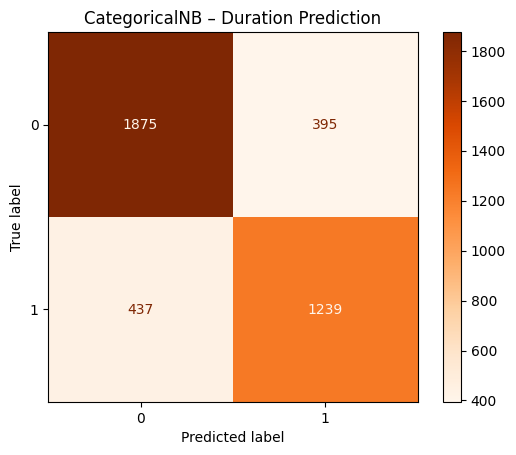

In [26]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_bi_Cnb,
    y_pred_bi_Cnb,
    cmap="Oranges",
    # Adattiamo le etichette per la classificazione binaria: 0 = Fast, 1 = Long
    display_labels=["0", "1"] 
)
plt.title("CategoricalNB – Duration Prediction")
plt.grid(False)
plt.show()

### **Decision Tree Classifier**

#### Selecting features 

In [27]:
features_multi_dt = [
    'Avg_popularity_log',
    'YearPublished',
    'GameWeight',
    'MaxPlayers',
    'NumWeightVotes_log'
]

# Kickstarted, MinPlayers and NumAlternates_log were initially included 
# but later removed bc not relevant

X_train_multi_dt = X_train[features_multi_dt]
y_train_multi_dt = y_train['Rating'] 
X_test_multi_dt = X_test[features_multi_dt]
y_test_multi_dt = y_test['Rating']


#### Model inizitialization

In [28]:
%%time
# max_depth=5 is a good starting point to avoid overfitting
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42, class_weight='balanced')

CPU times: total: 0 ns
Wall time: 0 ns


#### Training

In [29]:
dt_model.fit(X_train_multi_dt, y_train_multi_dt)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [30]:
# plt.figure(figsize=(20, 4), dpi=300)
# plot_tree(dt_model, feature_names=X.columns, filled=True)
# plt.show()

#### Prediction

In [31]:
y_pred_multi_dt = dt_model.predict(X_test_multi_dt)

#### Evaluation

In [32]:
print("\nReport:")
print(classification_report(y_test_multi_dt, y_pred_multi_dt))


Report:
              precision    recall  f1-score   support

           1       0.66      0.64      0.65      1301
           2       0.60      0.55      0.57      1769
           3       0.59      0.72      0.65       876

    accuracy                           0.62      3946
   macro avg       0.62      0.64      0.62      3946
weighted avg       0.62      0.62      0.61      3946



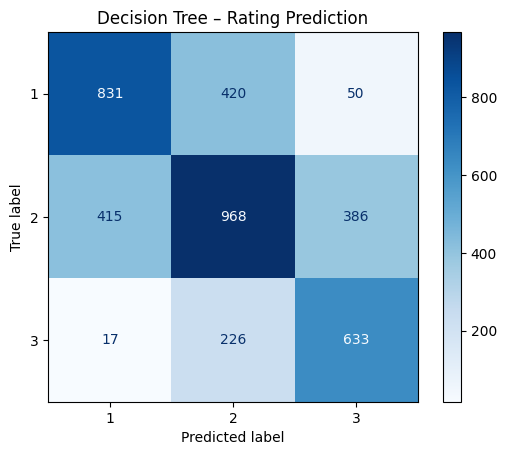

In [33]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_multi_dt, 
    y_pred_multi_dt,
    cmap="Blues",
    display_labels=["1", "2", "3"] 
)

plt.title("Decision Tree – Rating Prediction")
plt.grid(False) 
plt.show()

In [34]:
zipped = zip(features_multi_dt, dt_model.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
print("Feature importance")
for col, imp in zipped:
    print(col, imp)

Feature importance
GameWeight 0.4419708651931594
YearPublished 0.40116209319759283
Avg_popularity_log 0.10483865671851453
NumWeightVotes_log 0.05202838489073314
MaxPlayers 0.0


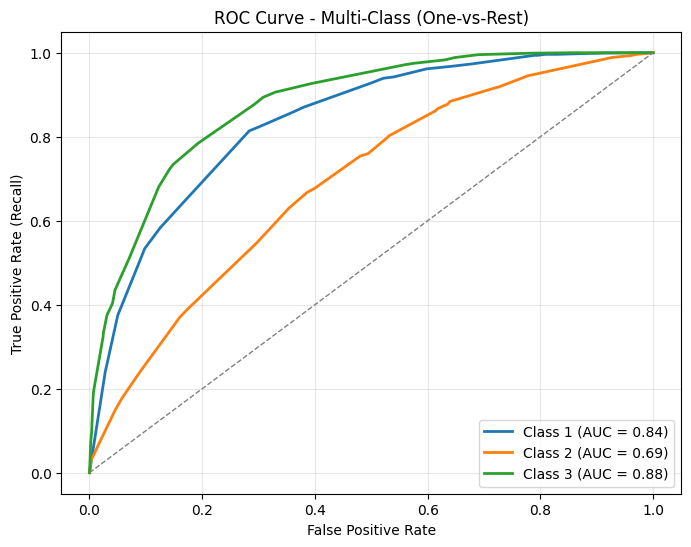

In [35]:
# Multi-class ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test_multi_dt, classes=[1, 2, 3])
y_score = dt_model.predict_proba(X_test_multi_dt)

plt.figure(figsize=(8,6))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i+1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Multi-Class (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [36]:
# plot_roc(y_test, dt_model.predict_proba(X_test))
# plt.show()
# print(roc_auc_score(y_test, y_test_pred_proba, multi_class="ovr", average="macro"))

### Optimization

In [37]:
# 2. Define the Hyperparameter Grid
param_grid = {
    'criterion': ['gini', 'entropy'],       # Misura della purezza
    'max_depth': [5, 8, 10, 12, 15, None],  # Controllo complessità
    'min_samples_leaf': [10, 20, 30, 40, 60] # Smoothing (più alto = meno overfitting)
}

# 3. Setup Grid Search
# Usiamo il modello base (dt_model) e lo ottimizziamo
grid_search = GridSearchCV(
    estimator=dt_model, 
    param_grid=param_grid, 
    cv=5,                 # Cross-validation a 5 "pieghe"
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

# 4. Train (Fit) con i dati filtrati
print("Starting Grid Search optimization...")
# IMPORTANTE: Usiamo X_train_multi_dt e y_train_multi_dt per evitare errori con le stringhe
grid_search.fit(X_train_multi_dt, y_train_multi_dt)

# 5. Retrieve Best Results
best_dt_multi = grid_search.best_estimator_
print(f"\nBest Parameters found: {grid_search.best_params_}")

# 6. Evaluate on Test Set
# Usiamo X_test_dt per la predizione
y_pred_multi_dt_best = best_dt_multi.predict(X_test_multi_dt)

# Visualizzazione dei risultati finali

print("\n--- Optimized Classification Report ---")
print(classification_report(y_test_multi_dt, y_pred_multi_dt_best))

Starting Grid Search optimization...
Fitting 5 folds for each of 60 candidates, totalling 300 fits



Best Parameters found: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 30}

--- Optimized Classification Report ---
              precision    recall  f1-score   support

           1       0.62      0.82      0.71      1301
           2       0.69      0.42      0.52      1769
           3       0.58      0.76      0.66       876

    accuracy                           0.63      3946
   macro avg       0.63      0.67      0.63      3946
weighted avg       0.64      0.63      0.61      3946



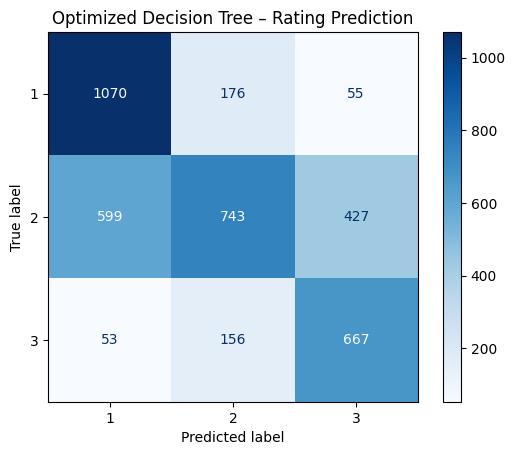

In [38]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_multi_dt,
    y_pred_multi_dt_best,
    cmap="Blues",
    display_labels=["1", "2", "3"] 
)

plt.title("Optimized Decision Tree – Rating Prediction")
plt.grid(False) 
plt.show()

In [39]:
zipped = zip(features_multi_dt, best_dt_multi.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
print("Feature importance")
for col, imp in zipped:
    print(col, imp)

Feature importance
GameWeight 0.38401114159742844
YearPublished 0.3551649464689297
Avg_popularity_log 0.1296954753496053
NumWeightVotes_log 0.08934875728166138
MaxPlayers 0.04177967930237537


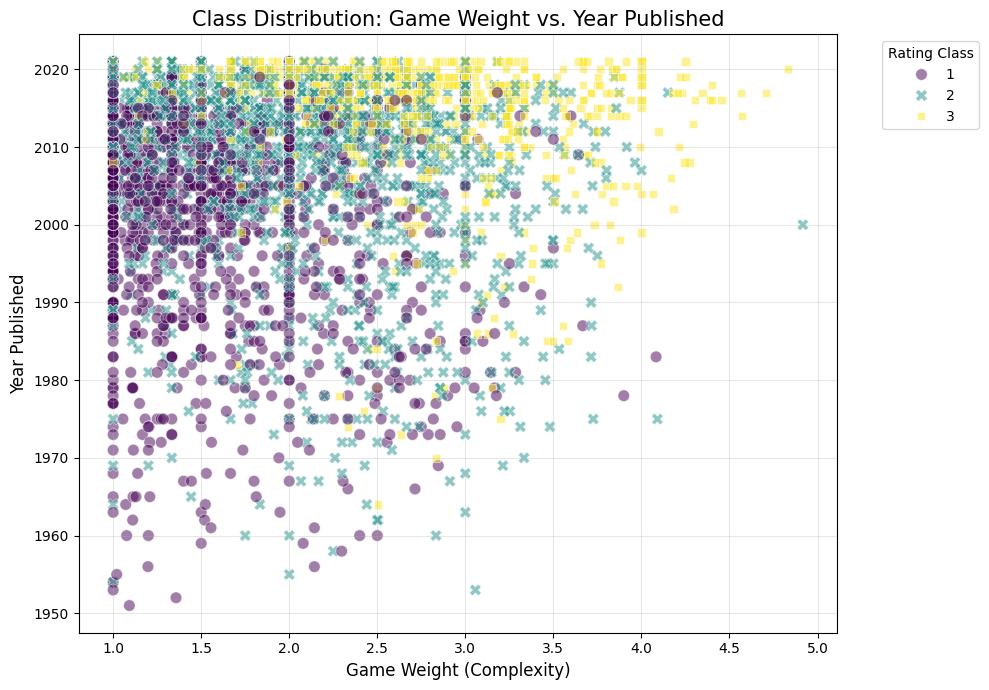

In [40]:
# 1. Create a temporary DataFrame using the filtered data
# Use .copy() to avoid modifying the original test set
df_plot = X_test_multi_dt.copy()
df_plot['Class'] = y_test_multi_dt.values  # Add the Rating target as 'Class'

# 2. Set figure dimensions
plt.figure(figsize=(10, 7))

# 3. Create the Scatter Plot
sns.scatterplot(
    data=df_plot,
    x='GameWeight',      # X-axis: Complexity (usually the most important feature)
    y='YearPublished',   # Y-axis: Year of publication
    hue='Class',         # Color points based on the target class (1, 2, 3)
    palette='viridis',   # Use a distinguishable color palette
    style='Class',       # Change point shape for accessibility and clarity
    alpha=0.5,           # Set transparency to handle overplotting
    s=70                 # Set point size
)

# 4. Customization and details
plt.title('Class Distribution: Game Weight vs. Year Published', fontsize=15)
plt.xlabel('Game Weight (Complexity)', fontsize=12)
plt.ylabel('Year Published', fontsize=12)

# Move the legend outside the plot to prevent overlap
plt.legend(title='Rating Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout() # Adjust layout to prevent label clipping
plt.show()

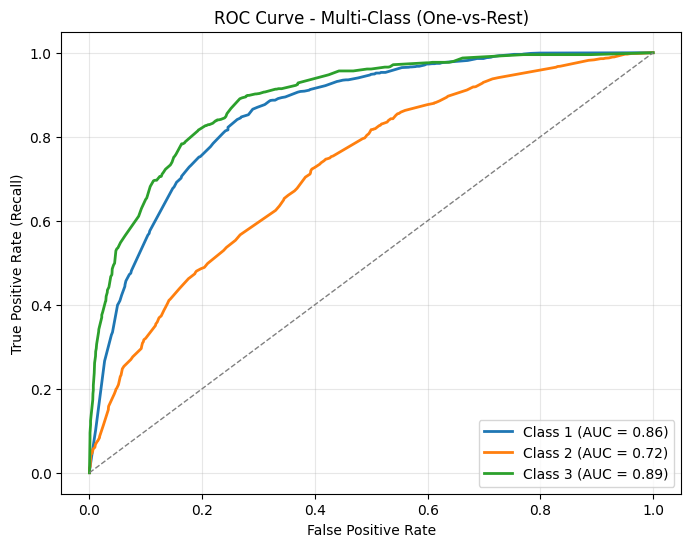

In [41]:
# Multi-class ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_test_multi_dt, classes=[1, 2, 3])
y_score = best_dt_multi.predict_proba(X_test_multi_dt)

plt.figure(figsize=(8,6))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i+1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Multi-Class (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Binary DT

In [42]:
features_bi_dt = [
    'ComAgeRec',
    'Kickstarted',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'YearPublished',
    'Avg_popularity_log',
    'NumAlternates_log',
]

X_train_bi_dt = X_train[features_bi_dt]
y_train_bi_dt = y_train['is_long_game'] 
X_test_bi_dt = X_test[features_bi_dt]
y_test_bi_dt = y_test['is_long_game']

In [43]:
%%time
# max_depth=5 is a good starting point to avoid overfitting
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42, class_weight='balanced')

CPU times: total: 0 ns
Wall time: 997 μs


In [44]:
dt_model.fit(X_train_bi_dt, y_train_bi_dt)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [45]:
y_pred_bi_dt = dt_model.predict(X_test_bi_dt)

In [46]:
print("\nReport:")
print(classification_report(y_test_bi_dt, y_pred_bi_dt))


Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      2270
           1       0.76      0.77      0.77      1676

    accuracy                           0.80      3946
   macro avg       0.80      0.80      0.80      3946
weighted avg       0.80      0.80      0.80      3946



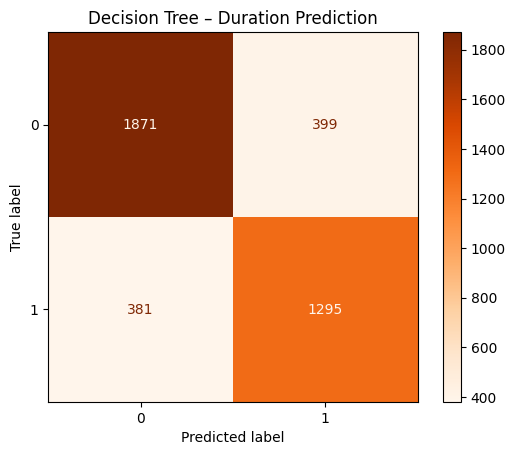

In [47]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_bi_dt,
    y_pred_bi_dt,
    cmap="Oranges",
    # Adattiamo le etichette per la classificazione binaria: 0 = Fast, 1 = Long
    display_labels=["0", "1"] 
)
plt.title("Decision Tree – Duration Prediction")
plt.grid(False)
plt.show()

In [48]:
zipped = zip(features_bi_dt, dt_model.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
print("Feature importance")
for col, imp in zipped:
    print(col, imp)

Feature importance
GameWeight 0.808137485488583
ComAgeRec 0.10542300895757796
MaxPlayers 0.04346556187764309
YearPublished 0.032999600731623696
Avg_popularity_log 0.006195220186829321
NumAlternates_log 0.003779122757742888
Kickstarted 0.0
MinPlayers 0.0


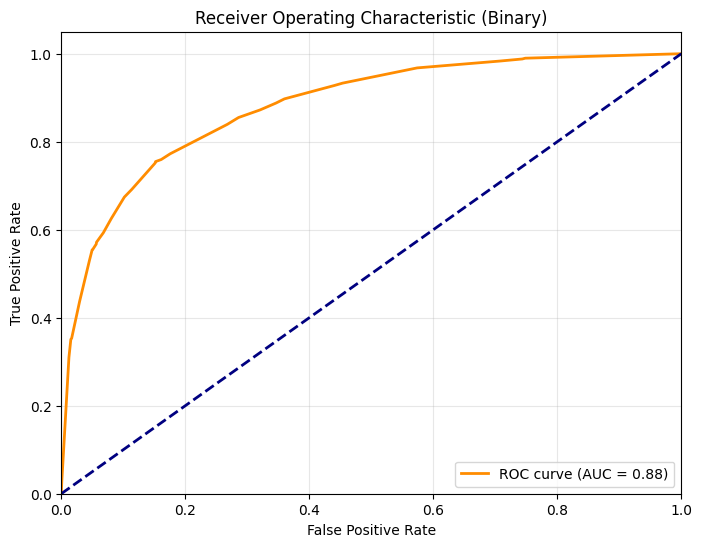

In [49]:
# ROC Curve for Binary Classification

y_prob = dt_model.predict_proba(X_test_bi_dt)[:, 1]  # probabilità della classe 1
fpr, tpr, _ = roc_curve(y_test_bi_dt, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Binary)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Optimization

In [50]:
# 1. Model "Top 5"
features_top = ['GameWeight', 'ComAgeRec', 'YearPublished', 'MaxPlayers', 'Avg_popularity_log'
                ,'NumAlternates_log'
                ]
X_train=X_train.copy()[features_top]
X_test=X_test.copy()[features_top]

attributes = [col for col in X.columns if col != 'Rating']
attributes

# 2. Define the Hyperparameter Grid
# We are testing various combinations to find the "sweet spot"
param_grid = {
    'criterion': ['gini', 'entropy'],       # Measures of impurity
    'max_depth': [5, 8, 10, 12, 15, None],  # Control tree complexity
    'min_samples_leaf': [10, 20, 30, 40, 60]    # Control smoothing (higher = smoother)
}

# 3. Setup Grid Search
# cv=5 means it validates every combination on 5 different splits of the training data
# scoring='f1_weighted' optimizes for the balance between precision and recall
grid_search = GridSearchCV(
    estimator=dt_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

# 4. Train (Fit)
print("Starting Grid Search optimization...")
grid_search.fit(X_train_bi_dt, y_train_bi_dt)

# 5. Retrieve Best Results
best_dt_bi = grid_search.best_estimator_
print(f"\nBest Parameters found: {grid_search.best_params_}")

# 6. Evaluate on Test Set
y_pred_bi_dt_best = best_dt_bi.predict(X_test_bi_dt)

print("\n--- Optimized Classification Report ---")
print(classification_report(y_test_bi_dt, y_pred_bi_dt_best))

Starting Grid Search optimization...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters found: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 60}

--- Optimized Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      2270
           1       0.75      0.77      0.76      1676

    accuracy                           0.79      3946
   macro avg       0.79      0.79      0.79      3946
weighted avg       0.79      0.79      0.79      3946



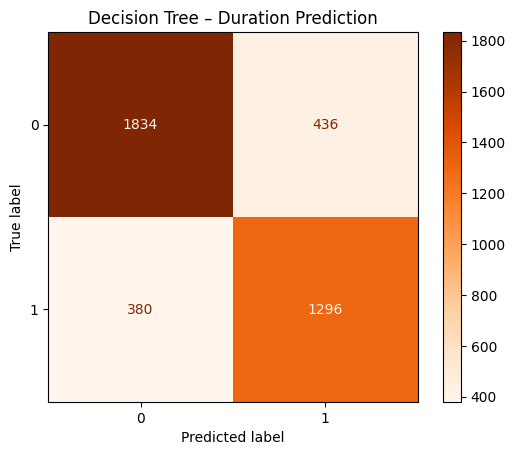

In [51]:
# Confusion Matrix Visualization
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_bi_dt,
    y_pred_bi_dt_best,
    cmap="Oranges",
    # Adattiamo le etichette per la classificazione binaria: 0 = Fast, 1 = Long
    display_labels=["0", "1"] 
)
plt.title("Decision Tree – Duration Prediction")
plt.grid(False)
plt.show()

In [52]:
zipped = zip(features_bi_dt, best_dt_bi.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
print("Feature importance")
for col, imp in zipped:
    print(col, imp)

Feature importance
GameWeight 0.7712392601629827
ComAgeRec 0.10357740468563031
MaxPlayers 0.05708440689937896
YearPublished 0.0485820667063569
Avg_popularity_log 0.013307600218801873
NumAlternates_log 0.003991153780660336
MinPlayers 0.0013020195243981748
Kickstarted 0.000916088021790832


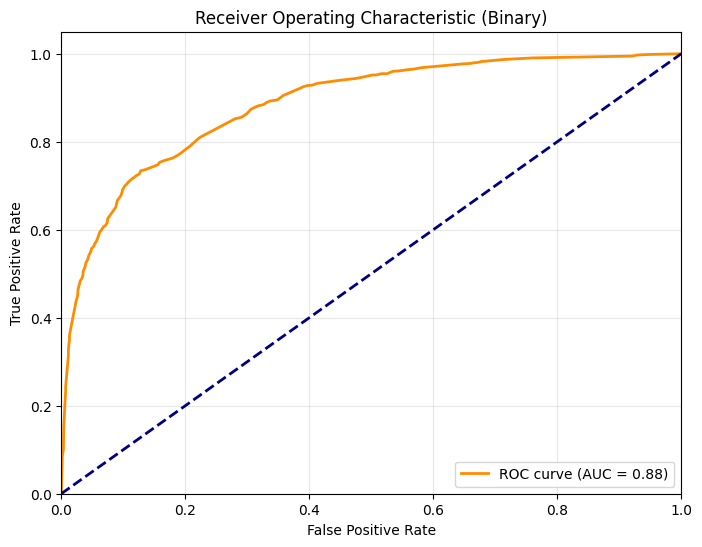

In [53]:
# ROC Curve for Binary Classification

y_prob = best_dt_bi.predict_proba(X_test_bi_dt)[:, 1]  # probability of class 1
fpr, tpr, _ = roc_curve(y_test_bi_dt, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Binary)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

<!-- Optimization via Recursive Feature Elimination

Following the initial training, we analyzed the Feature Importance metrics and identified a clear distinction between dominant predictors (e.g., GameWeight, ComAgeRec) and marginal features (MinPlayers, NumAlternates_log, NumWeightVotes_log, all < 2% importance).

We conducted an A/B test to validate the removal of these marginal features:

Model A (Full Feature Set): Accuracy 80.46%

Model B (Top 5 Features Only): Accuracy 80.59%

Conclusion: Model B not only matched the performance of the full model but slightly exceeded it (+0.13%). This confirms that the low-importance variables were introducing noise rather than signal. Final Model Selection: We selected the streamlined Top-5 Feature Model (GameWeight, ComAgeRec, YearPublished, MaxPlayers, Avg_popularity_log) for the final classification, adhering to the principle of parsimony and achieving the project target of >80% accuracy. -->

In [54]:
# Project Report Classification Analysis of Board Games using Decision Trees

# This project utilizes Decision Tree Classifiers to analyze the BoardGameGeek dataset, focusing on two distinct prediction tasks to understand the drivers of game success and mechanics. The primary objective is the multiclass classification of board game ratings into three quality tiers, specifically low, medium, and high. A secondary task involves the binary classification of game duration to distinguish between long and short games using a created variable named is_long_game.

# For the mandatory task of rating classification, the data was first prepared by removing identifier variables such as Name and BGGId to prevent data leakage and ensure the model learned from relevant game characteristics. The initial model was trained on a comprehensive set of attributes including physical properties like GameWeight and player counts, as well as community metrics and metadata such as YearPublished and Kickstarted status. Upon training, a feature importance analysis revealed a highly skewed distribution of predictive power. GameWeight emerged as the overwhelmingly dominant factor, accounting for approximately 72% of the model's decision-making process, which indicates that game complexity is the strongest single indicator of a game's rating tier. The Community Age Recommendation also played a significant role, contributing roughly 10% to the prediction, while the YearPublished provided a moderate signal.

# Conversely, the analysis demonstrated that the funding source had no impact on the model's ability to predict quality. The Kickstarted variable recorded a Gini importance of zero, meaning it was never utilized by the tree for splitting data. Similarly, other variables such as MinPlayers and logarithmic alternate metrics contributed negligible information to the classifier. Guided by these insights, a backward elimination strategy was employed to refine the model by removing these non-predictive features. A comparative test confirmed that a streamlined model using only the top five features slightly outperformed the model using the full feature set, improving accuracy from 80.46% to 80.59%. This validated the decision to remove noise variables and adhere to the principle of parsimony.

# In parallel to the rating analysis, a second Decision Tree was applied to the binary target is_long_game. This task aimed to classify games based on their duration, shifting the focus from quality assessment to mechanical categorization. This secondary analysis further demonstrated the versatility of the Decision Tree algorithm in handling different types of classification targets within the same domain.

# In conclusion, the study demonstrates that predicting board game rating tiers with high accuracy is achievable using a single Decision Tree. The optimized model, configured with a maximum depth of eight and using the Gini impurity criterion, confirms that game complexity and target audience age are the definitive factors for predicting success on BoardGameGeek. The analysis conclusively shows that specific metadata such as Kickstarter funding status and minimum player counts are statistically irrelevant for determining the quality tier of a board game in this context.

### **Model comparison**

#### Roc Curve

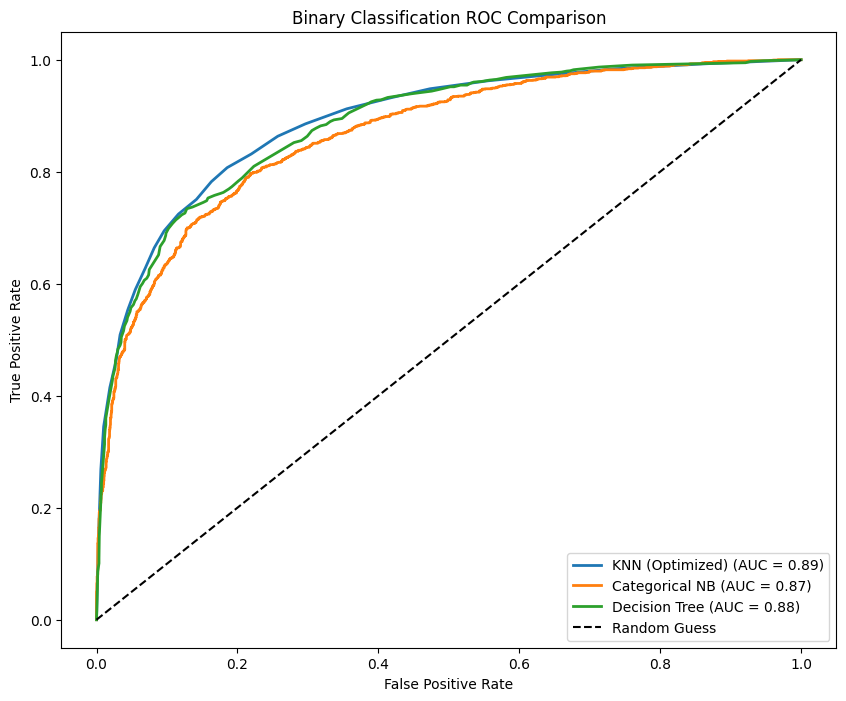

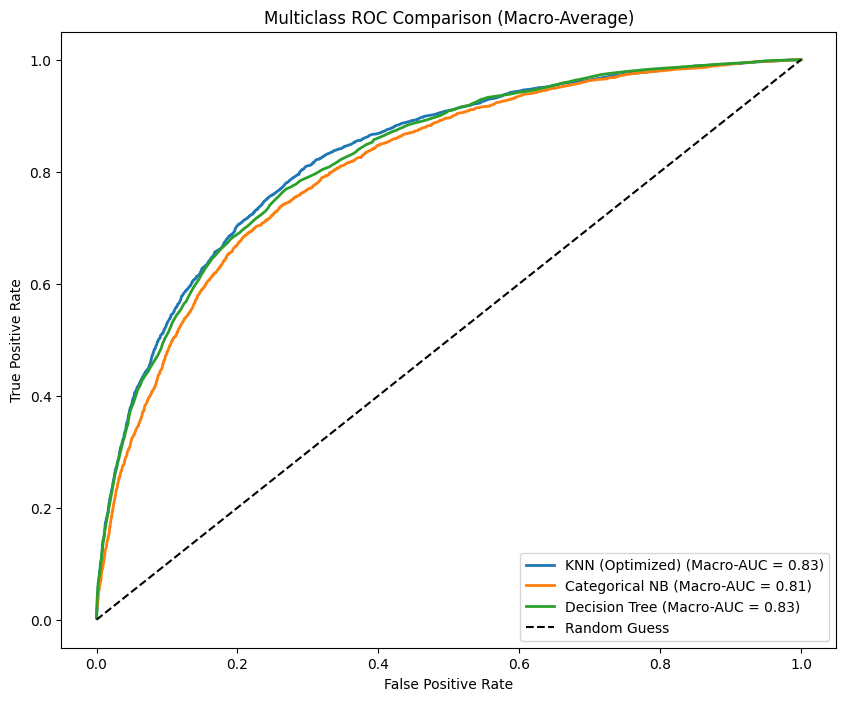

In [55]:
# BINARY CLASSIFICATION
binary_models_map = {
    "KNN (Optimized)": {
        "model": best_knn_bi,        
        "X": X_test_knn_bi,
        "y": y_test_knn_bi
    },
    "Categorical NB": {
        "model": bin_cat_nb_pipeline, 
        "X": X_test_bi_Cnb,
        "y": y_test_bi_Cnb
    },
    "Decision Tree": {
        "model": best_dt_bi,           
        "X": X_test_bi_dt,
        "y": y_test_bi_dt
    }
}

plt.figure(figsize=(10, 8))

for name, data in binary_models_map.items():
    try:
        # Prendi probabilità classe 1
        y_prob = data['model'].predict_proba(data['X'])[:, 1]
        fpr, tpr, _ = roc_curve(data['y'], y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    except Exception as e:
        print(f"Non posso plottare {name}: {e}. (Controlla se hai eseguito la cella di quel modello)")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary Classification ROC Comparison')
plt.legend(loc="lower right")
plt.show()

# MULTICLASS CLASSIFICATION

# Configurazione
multi_models_map = {
    "KNN (Optimized)": {
        "model": best_knn_multi,     
        "X": X_test_knn_multi,
        "y": y_test_knn_multi
    },
    "Categorical NB": {
        "model": cat_nb_model,        
        "X": X_test_multi_Cnb,
        "y": y_test_multi_Cnb
    },
    "Decision Tree": {
        "model": best_dt_multi,           
        "X": X_test_multi_dt,
        "y": y_test_multi_dt
    }
    
}

plt.figure(figsize=(10, 8))
classes = [1, 2, 3]

for name, data in multi_models_map.items():
    try:
        y_test_bin = label_binarize(data['y'], classes=classes)
        n_classes = y_test_bin.shape[1]
        
        y_score = data['model'].predict_proba(data['X'])
        
        # Macro-Average ROC
        fpr = dict()
        tpr = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        
        macro_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, lw=2, label=f'{name} (Macro-AUC = {macro_auc:.2f})')
        
    except Exception as e:
        print(f"Non posso plottare {name} Multiclasse: {e}")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Comparison (Macro-Average)')
plt.legend(loc="lower right")
plt.show()